In [1]:
import joblib

models = {
    "AQI": joblib.load("aqi_model_live.pkl"),
    "CACI": joblib.load("caci_model_live.pkl"),
    "TEMP": joblib.load("temp_model_live.pkl"),
    "HUMIDITY": joblib.load("humidity_model_live.pkl"),
    "PM2.5": joblib.load("pm25_model_live.pkl")
}

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("final_sensor_dataset.csv")

# Prepare target variables from the dataset
y2_aqi = df['AQI']
y2_caci = df['CACI']
y_temp = df['TEMP']
y_humidity = df['humidity']
y_pm25 = df['PM2.5']

# Split into test sets
split_idx = int(len(df) * 0.8)
y_test2_aqi = y2_aqi.iloc[split_idx:]
y_test2_caci = y2_caci.iloc[split_idx:]
y_test_temp = y_temp.iloc[split_idx:]
y_test_hum = y_humidity.iloc[split_idx:]
y_test_pm25 = y_pm25.iloc[split_idx:]

In [3]:
# Build model-specific datasets using each model's expected feature names
feature_cols = [col for col in df.columns if col not in ['timestamp', 'AQI', 'CACI', 'Air_Quality', 'CACI_Status']]
X = df[feature_cols]

target_col_map = {
    "AQI": "AQI",
    "CACI": "CACI",
    "TEMP": "TEMP",
    "HUMIDITY": "humidity",
    "PM2.5": "PM2.5"
}

model_data = {}

for name, model in models.items():
    df_features = df.copy()

    # Resolve common column-name casing differences once per model dataset
    column_lookup = {c.lower(): c for c in df_features.columns}
    canonical_columns = {
        "AQI": "aqi",
        "CACI": "caci",
        "PM2.5": "pm2.5",
        "PM10": "pm10",
        "TEMP": "temp",
        "humidity": "humidity",
        "gasValue": "gasvalue"
    }
    for canonical_name, lookup_key in canonical_columns.items():
        if lookup_key in column_lookup and canonical_name not in df_features.columns:
            df_features[canonical_name] = df_features[column_lookup[lookup_key]]

    # Fallback for datasets that do not include gasValue/gasvalue (use CO as proxy if present)
    if "gasValue" not in df_features.columns:
        co_col = column_lookup.get("co")
        if co_col is not None:
            df_features["gasValue"] = df_features[co_col]

    # Refresh lookup after derived/fallback columns are added
    column_lookup = {c.lower(): c for c in df_features.columns}

    # Add derived time features if needed by the trained model
    model_features = list(getattr(model, "feature_names_in_", []))
    if "timestamp" in df_features.columns and model_features:
        ts = pd.to_datetime(df_features["timestamp"], errors="coerce")
        df_features["hour"] = ts.dt.hour
        df_features["day"] = ts.dt.day
        df_features["month"] = ts.dt.month
        df_features["weekday"] = ts.dt.weekday
        df_features["year"] = ts.dt.year

        # Add cyclic encodings on demand (hour_sin/hour_cos, weekday_sin/weekday_cos, etc.)
        cyc_periods = {
            "hour": 24,
            "day": 31,
            "month": 12,
            "weekday": 7
        }
        for base, period in cyc_periods.items():
            sin_col = f"{base}_sin"
            cos_col = f"{base}_cos"
            if sin_col in model_features and base in df_features.columns:
                df_features[sin_col] = np.sin(2 * np.pi * df_features[base] / period)
            if cos_col in model_features and base in df_features.columns:
                df_features[cos_col] = np.cos(2 * np.pi * df_features[base] / period)

    # Create lag features on demand (e.g., AQI_lag1, AQI_lag2)
    for feat in model_features:
        if feat in df_features.columns:
            continue
        if "_lag" in feat:
            base_col, lag_txt = feat.rsplit("_lag", 1)
            if lag_txt.isdigit():
                base_col_resolved = base_col if base_col in df_features.columns else column_lookup.get(base_col.lower())
                if base_col_resolved is not None:
                    df_features[feat] = df_features[base_col_resolved].shift(int(lag_txt))

    # Fallback for models without feature_names_in_
    if not model_features:
        model_features = feature_cols

    # Resolve requested model features case-insensitively
    missing = []
    resolved_features = []
    for feat in model_features:
        if feat in df_features.columns:
            resolved_features.append(feat)
            continue
        feat_match = column_lookup.get(feat.lower())
        if feat_match is not None:
            # Create the exact expected feature name for downstream consistency
            df_features[feat] = df_features[feat_match]
            resolved_features.append(feat)
        else:
            missing.append(feat)

    if missing:
        raise ValueError(f"Missing features for {name}: {missing}")

    X_model = df_features[resolved_features].dropna().copy()

    target_name = target_col_map[name]
    target_resolved = target_name if target_name in df.columns else {c.lower(): c for c in df.columns}.get(target_name.lower())
    if target_resolved is None:
        raise ValueError(f"Missing target column for {name}: {target_name}")
    y_model = df[target_resolved].loc[X_model.index].copy()

    split_idx_model = int(len(X_model) * 0.8)
    model_data[name] = {
        "X_train": X_model.iloc[:split_idx_model],
        "X_test": X_model.iloc[split_idx_model:],
        "y_train": y_model.iloc[:split_idx_model],
        "y_test": y_model.iloc[split_idx_model:]
    }

In [4]:
targets = {
    "AQI": (y_test2_aqi, y2_aqi),
    "CACI": (y_test2_caci, y2_caci),
    "TEMP": (y_test_temp, y_temp),
    "HUMIDITY": (y_test_hum, y_humidity),
    "PM2.5": (y_test_pm25, y_pm25)
}

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in models.items():
    data = model_data[name]
    y_test = data["y_test"]
    pred = model.predict(data["X_test"])

    print(f"\n{name} MODEL PERFORMANCE")
    print("MAE :", round(mean_absolute_error(y_test, pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))
    print("R2  :", round(r2_score(y_test, pred), 3))


AQI MODEL PERFORMANCE
MAE : 6.623
RMSE: 11.266
R2  : 0.984

CACI MODEL PERFORMANCE
MAE : 2.005
RMSE: 2.64
R2  : 0.979

TEMP MODEL PERFORMANCE
MAE : 0.829
RMSE: 0.99
R2  : 0.994

HUMIDITY MODEL PERFORMANCE
MAE : 3.321
RMSE: 4.13
R2  : 0.97

PM2.5 MODEL PERFORMANCE
MAE : 5.043
RMSE: 9.633
R2  : 0.987


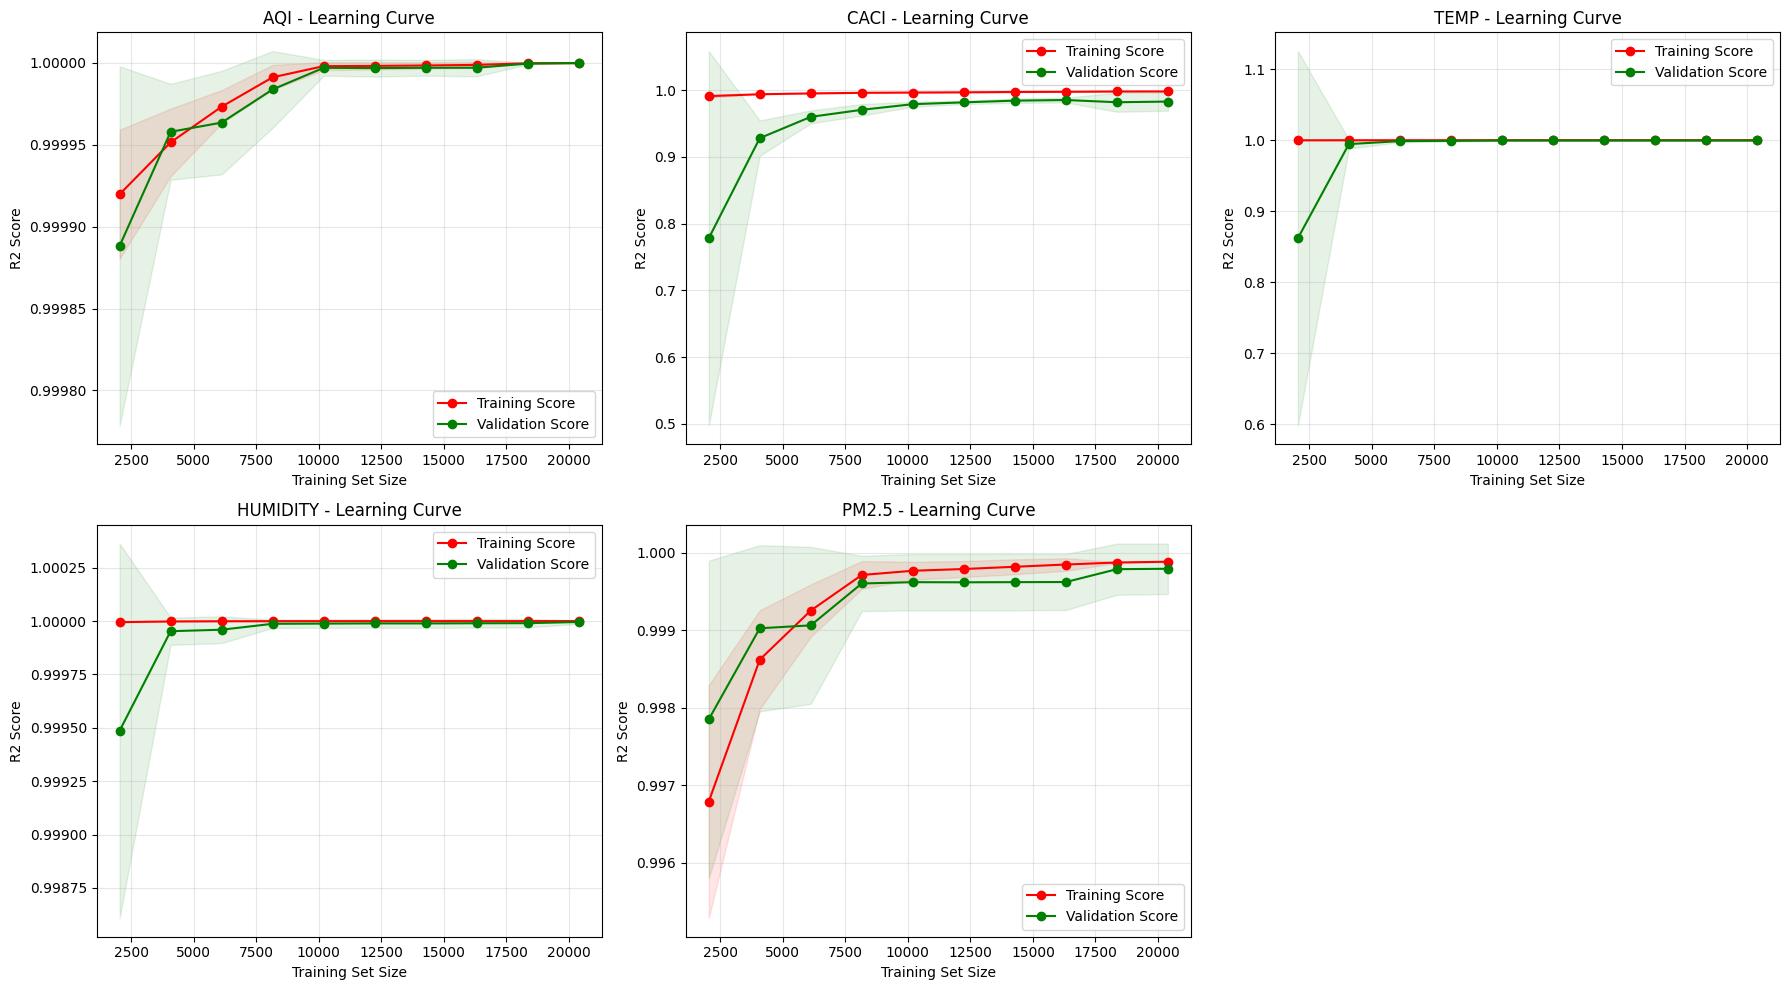

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate Learning Curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]
    data = model_data[name]

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        data["X_train"],
        data["y_train"],
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="r2"
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, "o-", color="r", label="Training Score")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    ax.plot(train_sizes, val_mean, "o-", color="g", label="Validation Score")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="g")

    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("R2 Score")
    ax.set_title(f"{name} - Learning Curve")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

axes[5].axis("off")
plt.tight_layout()
plt.show()

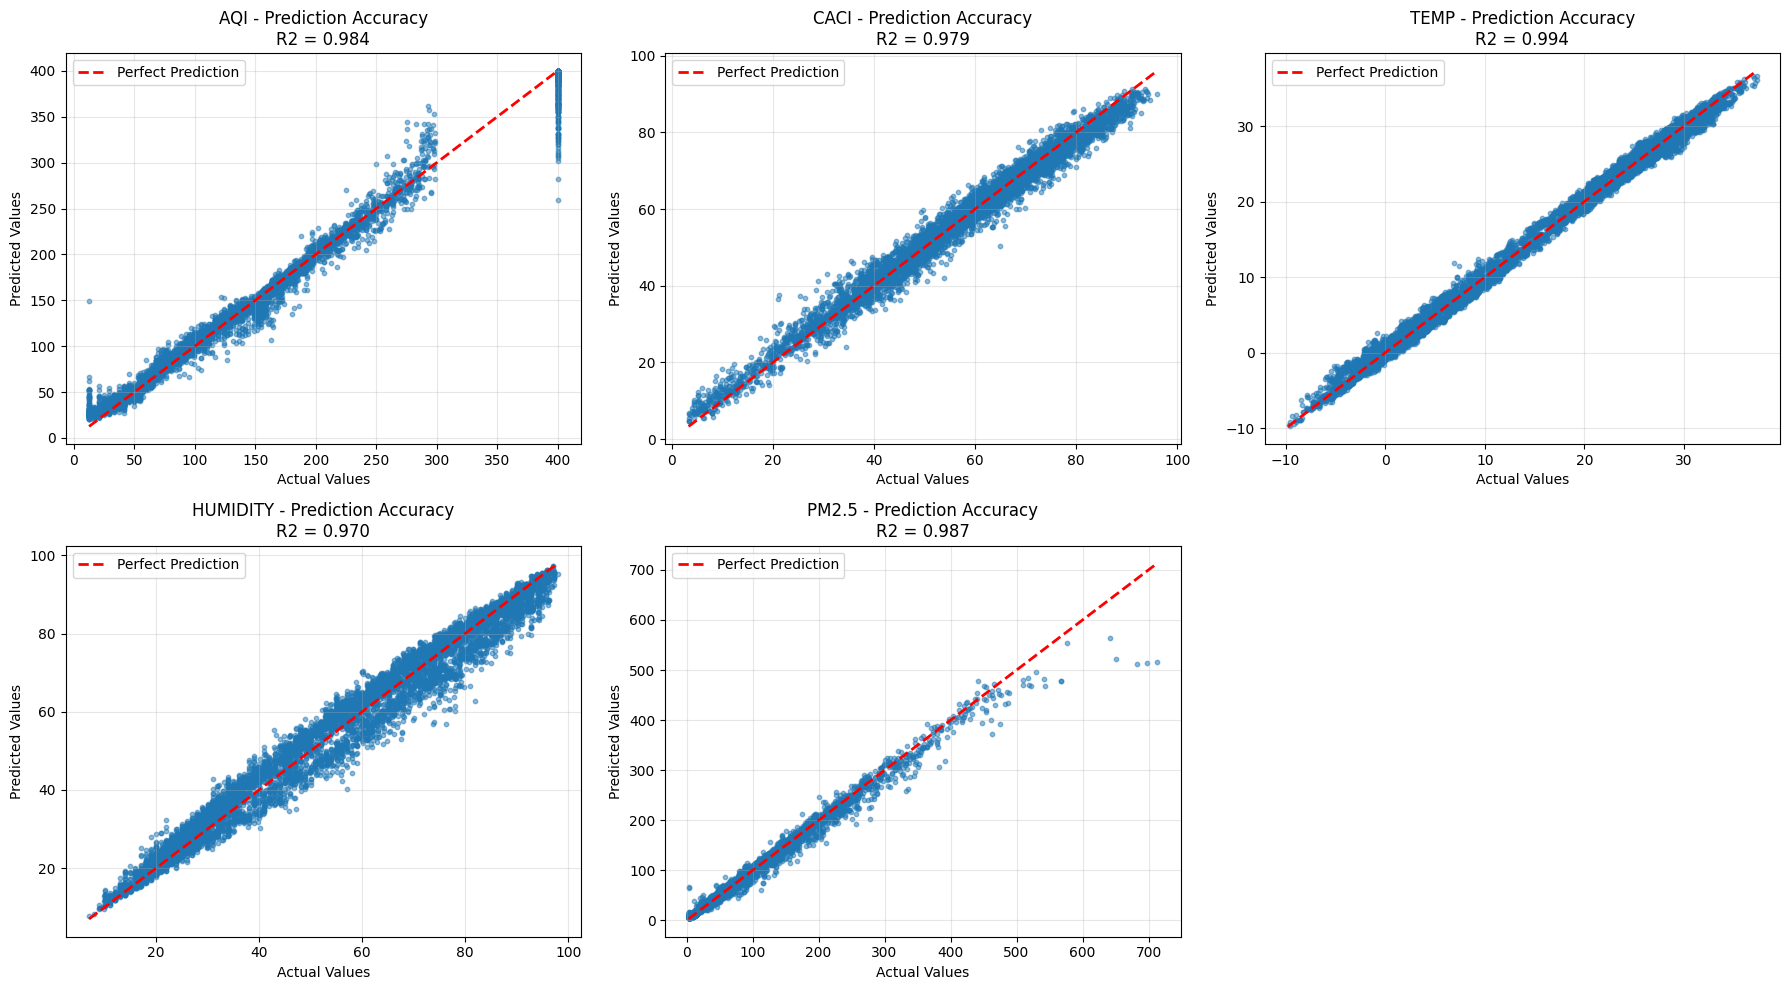


MODEL PERFORMANCE SUMMARY
Model           MAE             RMSE            R2 Score       
----------------------------------------------------------------------
AQI             6.623           11.266          0.984          
CACI            2.005           2.640           0.979          
TEMP            0.829           0.990           0.994          
HUMIDITY        3.321           4.130           0.970          
PM2.5           5.043           9.633           0.987          


In [8]:
# Prediction Accuracy - Actual vs Predicted
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

predictions_summary = {}

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]

    data = model_data[name]
    y_test = data["y_test"]
    pred = model.predict(data["X_test"])

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    predictions_summary[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    # Scatter plot: Actual vs Predicted
    ax.scatter(y_test, pred, alpha=0.5, s=10)

    # Perfect prediction line
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction")

    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(f"{name} - Prediction Accuracy\nR2 = {r2:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[5].axis("off")
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(f"{'Model':<15} {'MAE':<15} {'RMSE':<15} {'R2 Score':<15}")
print("-" * 70)
for name, metrics in predictions_summary.items():
    print(f"{name:<15} {metrics['MAE']:<15.3f} {metrics['RMSE']:<15.3f} {metrics['R2']:<15.3f}")
print("=" * 70)

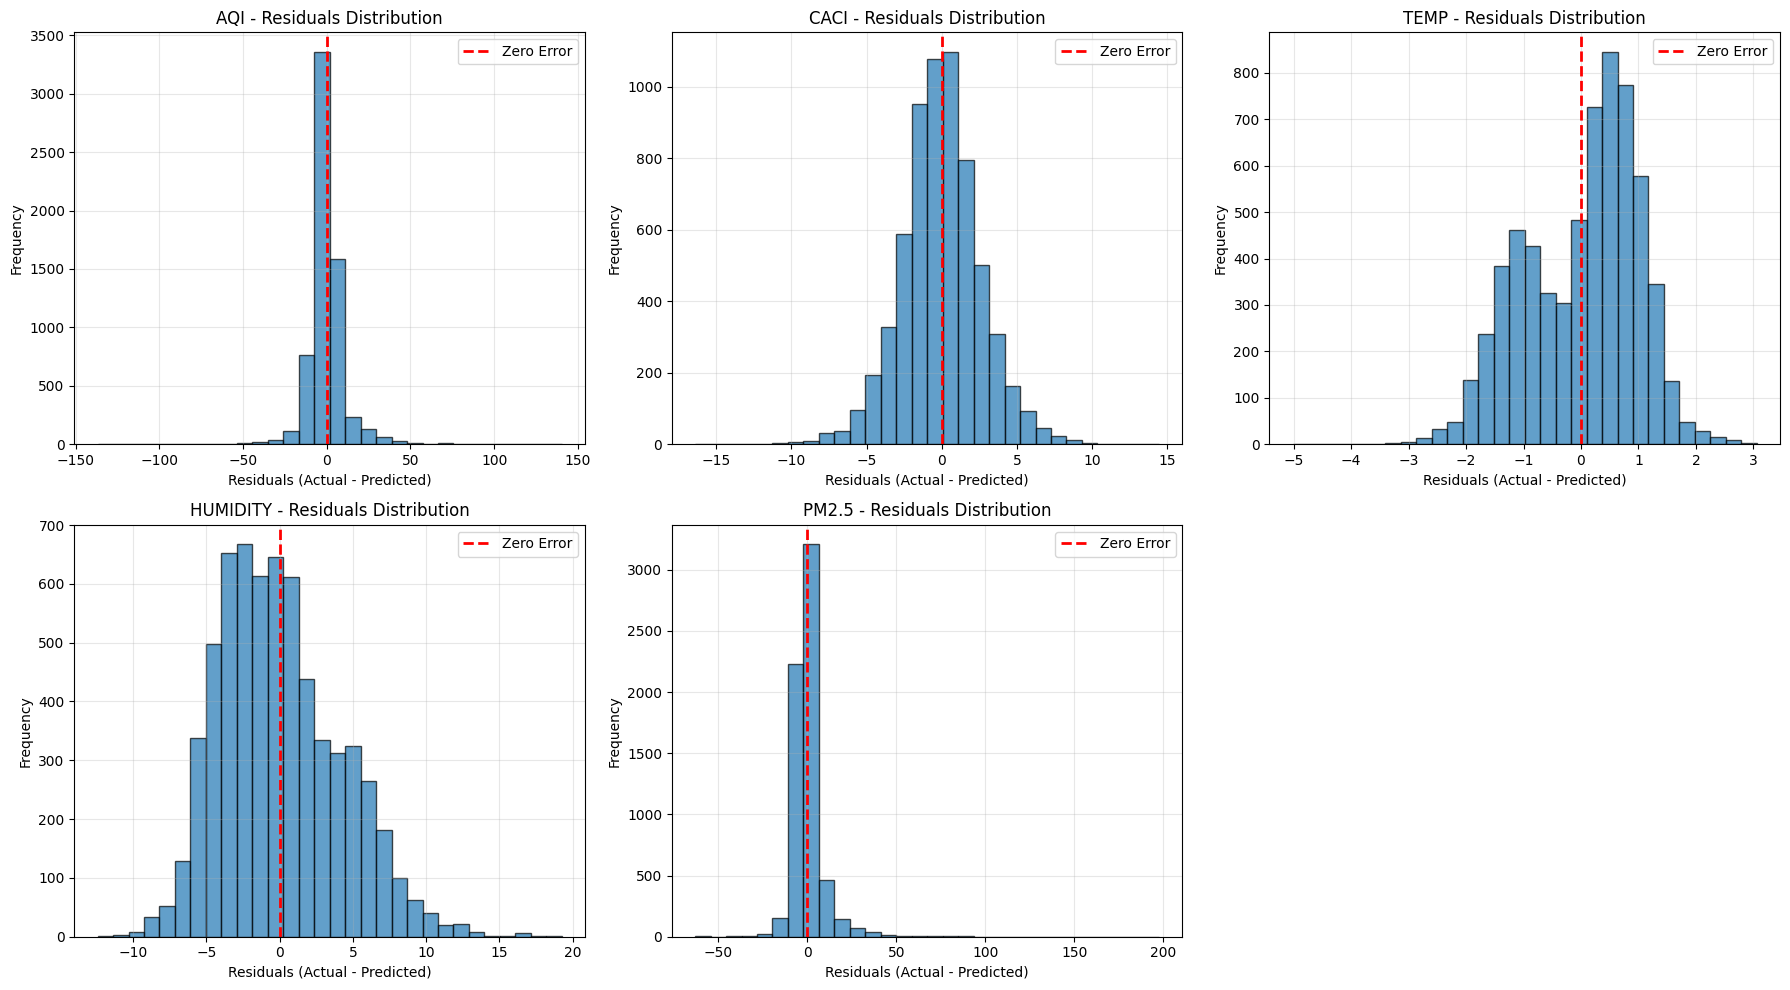

In [10]:
# Residuals Analysis - Prediction Errors
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]

    data = model_data[name]
    y_test = data["y_test"]
    pred = model.predict(data["X_test"])

    residuals = y_test.values - pred

    # Residuals histogram
    ax.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
    ax.axvline(x=0, color="r", linestyle="--", lw=2, label="Zero Error")
    ax.set_xlabel("Residuals (Actual - Predicted)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} - Residuals Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[5].axis("off")
plt.tight_layout()
plt.show()